# Notebook 4 — Generators & Merit Order

This notebook brings together fuel prices and availability into complete **Generator** objects, and shows how the **merit order** determines which plants run and what electricity costs.

Topics:
1. The `Generator` class — combining technical, economic, and stochastic parameters
2. The `ITALIAN_MIX` — what Italy's fleet looks like
3. The merit-order rule — sort by SRMC, stack until load is met
4. Capital cost recovery — CAPEX through the CRF
5. How adding technologies shifts the merit order

**Runtime**: < 10 seconds

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from energy_sim.models import TimeGrid
from energy_sim.generators import (
    Generator, build_generators, FuelPriceModel, CarbonPriceModel,
    ConstantFuelPrice,
)
from energy_sim.config import (
    ITALIAN_MIX, GAS_SCENARIOS, P_PEAK_GW, DISCOUNT_RATE,
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

## 1. The Italian Generation Mix

The default mix is calibrated to the Italian power system (~60 GW peak). Let's explore it:

Technology      Cap (GW)   Eff  H (s)  Min%   VOM    EF   CAPEX  Life
--------------------------------------------------------------------------------
gas                 45.0  0.58    4.5   40%   3.0  0.20     900    27
solar               30.0  1.00    0.0    0%   0.5  0.00     550    28
wind                13.0  1.00    0.0    0%   1.5  0.00    1250    22
nuclear              0.0  0.33    6.0   50%   2.5  0.00    5500    60
coal                 0.0  0.40    5.0   45%   4.0  0.34    1500    40
hydro_mustrun        8.0  1.00    3.5  100%   0.0  0.00       0    80
────────────────────────────────────────────────────────────────────────────────
Total               96.0 GW


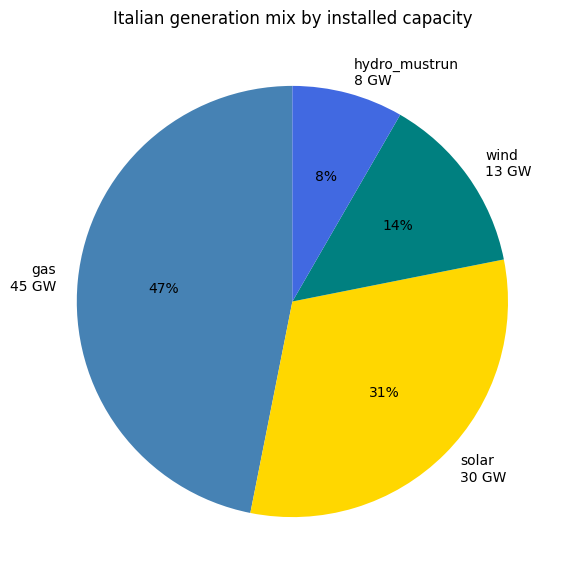

In [2]:
print(f"{'Technology':<14s} {'Cap (GW)':>9s} {'Eff':>5s} {'H (s)':>6s} {'Min%':>5s} "
      f"{'VOM':>5s} {'EF':>5s} {'CAPEX':>7s} {'Life':>5s}")
print("-" * 80)
total_cap = 0
for tech, p in ITALIAN_MIX.items():
    total_cap += p['capacity_gw']
    print(f"{tech:<14s} {p['capacity_gw']:9.1f} {p['efficiency']:5.2f} "
          f"{p['h_inertia']:6.1f} {p['min_stable_pct']:5.0%} "
          f"{p['vom_eur_mwh']:5.1f} {p['emission_factor']:5.2f} "
          f"{p['capex_per_kw']:7.0f} {p['lifetime_years']:5.0f}")

print(f"{'':─<80}")
print(f"{'Total':<14s} {total_cap:9.1f} GW")

# Pie chart
active = {k: v for k, v in ITALIAN_MIX.items() if v['capacity_gw'] > 0}
fig, ax = plt.subplots(figsize=(7, 7))
colors_map = {'gas': 'steelblue', 'solar': 'gold', 'wind': 'teal',
              'hydro_mustrun': 'royalblue', 'nuclear': 'purple', 'coal': 'brown'}
ax.pie([v['capacity_gw'] for v in active.values()],
       labels=[f"{k}\n{v['capacity_gw']:.0f} GW" for k, v in active.items()],
       colors=[colors_map.get(k, 'gray') for k in active.keys()],
       autopct='%1.0f%%', startangle=90)
ax.set_title('Italian generation mix by installed capacity')
plt.show()

## 2. Building generators and preparing a run

The `build_generators()` factory routes each technology to the appropriate fuel and availability models. Let's build the fleet and simulate one year:

In [3]:
tg = TimeGrid()
rng = np.random.default_rng(42)
co2 = CarbonPriceModel()  # default: mu=65, sigma=10, theta=0.05

gens = build_generators(ITALIAN_MIX, GAS_SCENARIOS['base'])
for g in gens:
    g.prepare_run(tg, rng, co2)

print(f"Built {len(gens)} generators:\n")
for g in gens:
    avg_srmc = g.srmc().mean()
    avg_avail = g._avail_profile.mean()
    print(f"  {g.name:<14s}  cap={g.capacity_gw:5.1f} GW  "
          f"avg_SRMC={avg_srmc:6.1f} EUR/MWh  "
          f"avg_CF={avg_avail:.2f}  "
          f"sync={'yes' if g.is_synchronous else 'no'}")

Built 4 generators:

  gas             cap= 45.0 GW  avg_SRMC=  85.1 EUR/MWh  avg_CF=1.00  sync=yes
  solar           cap= 30.0 GW  avg_SRMC=   0.5 EUR/MWh  avg_CF=0.14  sync=no
  wind            cap= 13.0 GW  avg_SRMC=   1.5 EUR/MWh  avg_CF=0.20  sync=no
  hydro_mustrun   cap=  8.0 GW  avg_SRMC=   0.0 EUR/MWh  avg_CF=1.00  sync=yes


## 3. The Merit Order

The **merit order** is the fundamental rule of European day-ahead electricity markets:

1. Sort all generators by increasing SRMC
2. Dispatch them in order until the cumulative capacity meets the load
3. The **marginal unit** (last dispatched) sets the electricity price for everyone

This means cheap renewables and nuclear earn *infra-marginal rent* — they get paid the gas price even though their cost is near zero.

In [4]:
# Snapshot at a specific timestep (a July afternoon, high load)
t = 182 * 96 + 52  # July 1, 13:00

srmc_at_t = [(g.name, g.srmc()[t], g.available_power_pu()[t] * P_PEAK_GW) for g in gens]
srmc_at_t.sort(key=lambda x: x[1])

print(f"Merit order at t={t} (July 1, 13:00):\n")
print(f"{'Rank':<5s} {'Generator':<14s} {'SRMC (EUR/MWh)':>15s} {'Available (GW)':>15s}")
print("-" * 55)
cumulative = 0
for i, (name, srmc, avail_gw) in enumerate(srmc_at_t):
    cumulative += avail_gw
    print(f"{i+1:<5d} {name:<14s} {srmc:15.1f} {avail_gw:15.1f}")
print(f"\nTotal available: {cumulative:.1f} GW")

Merit order at t=17524 (July 1, 13:00):

Rank  Generator       SRMC (EUR/MWh)  Available (GW)
-------------------------------------------------------
1     hydro_mustrun              0.0             8.0
2     solar                      0.5            28.0
3     wind                       1.5             1.4
4     gas                       76.9            45.0

Total available: 82.4 GW


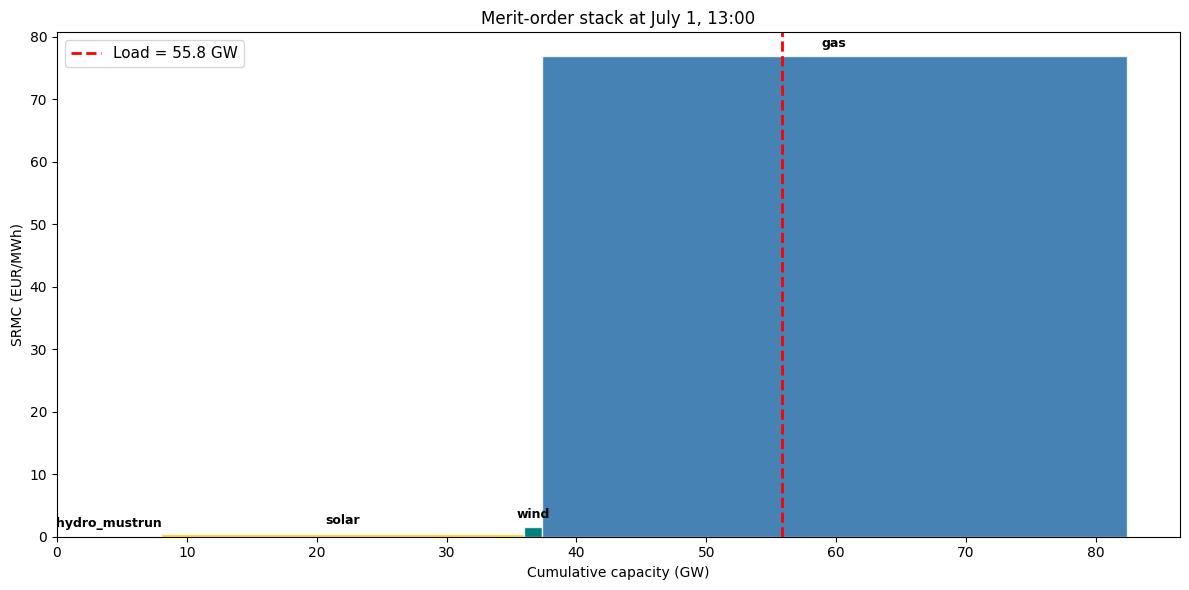

In [5]:
# Visualize as a merit-order stack diagram
fig, ax = plt.subplots(figsize=(12, 6))

cumul = 0
for name, srmc, avail_gw in srmc_at_t:
    color = colors_map.get(name, 'gray')
    ax.barh(0, avail_gw, left=cumul, height=srmc, align='edge',
            color=color, edgecolor='white', lw=0.5)
    # Stacked bar (width = capacity, height = SRMC)
    ax.bar(cumul + avail_gw/2, srmc, width=avail_gw,
           color=color, alpha=0.8, edgecolor='white')
    if avail_gw > 1:  # only label if visible
        ax.text(cumul + avail_gw/2, srmc + 1, name,
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    cumul += avail_gw

# Draw load line
from energy_sim.models import LoadProfile
lp = LoadProfile(tg)
load = lp.generate()
load_gw_at_t = load[t] * P_PEAK_GW
ax.axvline(load_gw_at_t, color='red', ls='--', lw=2, label=f'Load = {load_gw_at_t:.1f} GW')

ax.set_xlabel('Cumulative capacity (GW)')
ax.set_ylabel('SRMC (EUR/MWh)')
ax.set_title('Merit-order stack at July 1, 13:00')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 4. Capital Cost Recovery

SRMC tells us the **running cost**, but building a power plant also costs money. The **Capital Recovery Factor** (CRF) spreads CAPEX over the plant's lifetime:

$$\text{CRF} = \frac{r(1+r)^n}{(1+r)^n - 1}$$

Then the fixed cost per MWh depends on the capacity factor:

$$\text{CAPEX}_{\text{MWh}} = \frac{\text{CAPEX}_{\text{kW}} \times \text{CRF} + \text{FOM}}{\text{CF} \times 8760} \times 1000$$

In [6]:
r = DISCOUNT_RATE  # 7%

print(f"Discount rate: {r:.0%}\n")
print(f"{'Technology':<14s} {'CAPEX':>7s} {'Life':>5s} {'CRF':>6s} {'CF':>5s} "
      f"{'Fixed':>8s} {'SRMC':>6s} {'LCOE':>8s}")
print("-" * 70)

avg_cf = {'nuclear': 0.85, 'gas': 0.50, 'coal': 0.55,
          'solar': 0.15, 'wind': 0.25, 'hydro_mustrun': 0.90}

for tech, p in ITALIAN_MIX.items():
    if p['capacity_gw'] == 0 and tech not in ['nuclear', 'coal']:
        continue
    n = p['lifetime_years']
    crf = r * (1 + r)**n / ((1 + r)**n - 1)
    cf = avg_cf.get(tech, 0.5)
    fixed = (p['capex_per_kw'] * crf + p['fom_eur_kw_yr']) / (cf * 8760) * 1000
    srmc_avg = p['vom_eur_mwh']  # simplified for non-thermal
    if tech == 'gas':
        srmc_avg = 35/0.58 + 65*0.20/0.58 + 3  # base case
    elif tech == 'coal':
        srmc_avg = 12/0.40 + 65*0.34/0.40 + 4
    elif tech == 'nuclear':
        srmc_avg = 3/0.33 + 2.5
    lcoe = fixed + srmc_avg
    print(f"{tech:<14s} {p['capex_per_kw']:7.0f} {n:5.0f} {crf:6.3f} {cf:5.0%} "
          f"{fixed:8.1f} {srmc_avg:6.1f} {lcoe:8.1f}")

Discount rate: 7%

Technology       CAPEX  Life    CRF    CF    Fixed   SRMC     LCOE
----------------------------------------------------------------------
gas                900    27  0.083   50%     21.7   85.8    107.5
solar              550    28  0.082   15%     42.1    0.5     42.6
wind              1250    22  0.090   25%     66.2    1.5     67.7
nuclear           5500    60  0.071   85%     63.4   11.6     74.9
coal              1500    40  0.075   55%     30.6   89.2    119.9
hydro_mustrun        0    80  0.070   90%      0.0    0.0      0.0


## 5. How adding technologies shifts the merit order

Adding cheap-SRMC capacity (nuclear, more solar) pushes expensive generators out of the merit order, lowering prices — but also reducing the revenue of *all* generators (the **merit-order effect**).

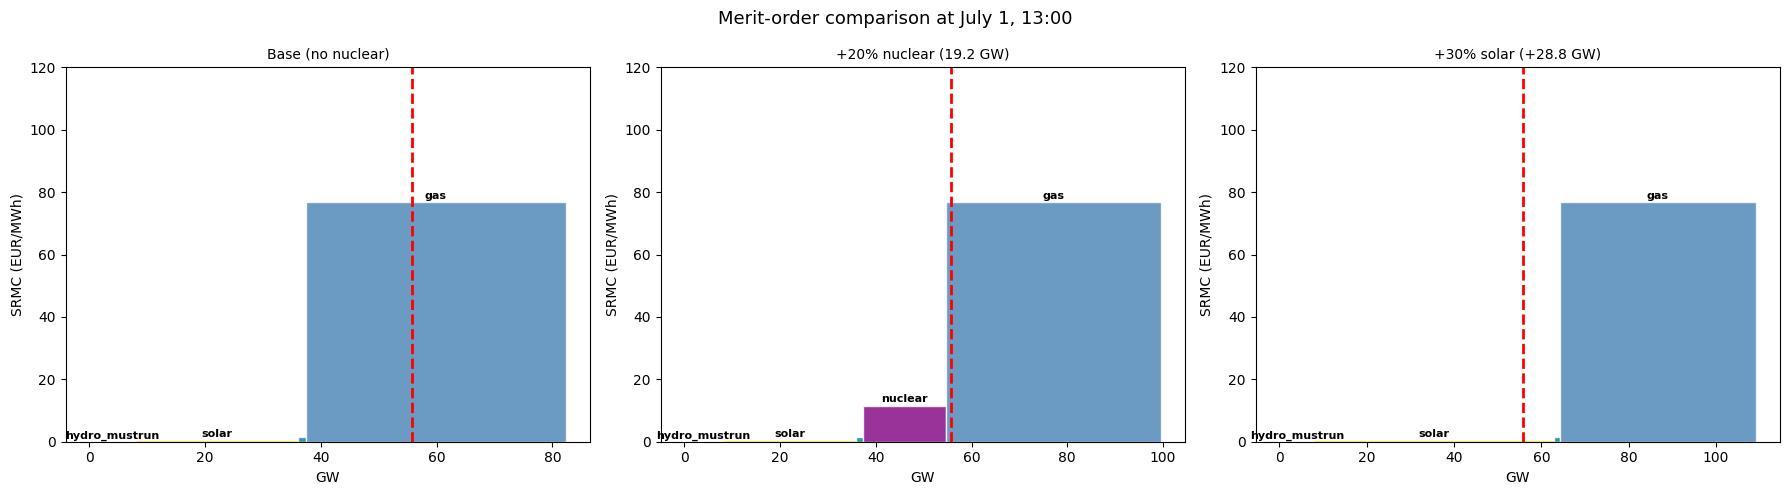

In [7]:
from copy import deepcopy

scenarios = {
    'Base (no nuclear)': ITALIAN_MIX,
    '+20% nuclear (19.2 GW)': None,
    '+30% solar (+28.8 GW)': None,
}

# Build modified mixes
total_cap = sum(v['capacity_gw'] for v in ITALIAN_MIX.values())

mix_nuclear = deepcopy(ITALIAN_MIX)
mix_nuclear['nuclear']['capacity_gw'] = total_cap * 0.20
scenarios['+20% nuclear (19.2 GW)'] = mix_nuclear

mix_solar = deepcopy(ITALIAN_MIX)
mix_solar['solar']['capacity_gw'] = ITALIAN_MIX['solar']['capacity_gw'] + total_cap * 0.30
scenarios['+30% solar (+28.8 GW)'] = mix_solar

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, mix) in zip(axes, scenarios.items()):
    gens_s = build_generators(mix, GAS_SCENARIOS['base'])
    rng_s = np.random.default_rng(42)
    co2_s = CarbonPriceModel()
    for g in gens_s:
        g.prepare_run(tg, rng_s, co2_s)
    
    # Stack at t (July 1, 13:00)
    stack = [(g.name, g.srmc()[t], g.available_power_pu()[t] * P_PEAK_GW) for g in gens_s]
    stack.sort(key=lambda x: x[1])
    
    cumul = 0
    for name, srmc, avail_gw in stack:
        color = colors_map.get(name, 'gray')
        ax.bar(cumul + avail_gw/2, srmc, width=avail_gw,
               color=color, alpha=0.8, edgecolor='white')
        if avail_gw > 2:
            ax.text(cumul + avail_gw/2, srmc + 1, name,
                    ha='center', fontsize=8, fontweight='bold')
        cumul += avail_gw
    
    ax.axvline(load_gw_at_t, color='red', ls='--', lw=2)
    ax.set_xlabel('GW')
    ax.set_ylabel('SRMC (EUR/MWh)')
    ax.set_title(label, fontsize=10)
    ax.set_ylim(0, 120)

plt.suptitle('Merit-order comparison at July 1, 13:00', fontsize=13)
plt.tight_layout()
plt.show()

## Key Takeaways

1. **Generators** combine a fuel model, an availability model, and technical/economic parameters into a single dispatchable unit.
2. The **merit order** sorts by SRMC: renewables and nuclear at the bottom, gas at the top. The marginal (most expensive) running unit sets the price.
3. **Infra-marginal rent**: cheap generators earn the difference between their SRMC and the market price. This funds their CAPEX recovery.
4. The **merit-order effect**: adding cheap capacity (nuclear, solar) pushes down the clearing price, benefiting consumers but cannibalizing all generators' revenue.
5. **LCOE** (CAPEX + SRMC) determines long-run investment signals, while **SRMC** alone drives short-run dispatch.

**Next notebook**: [05 — Dispatch Engine](./05_dispatch_engine.ipynb) — the full 4-phase dispatch with inertia constraints.